In [1]:
def write_pointcloud(filename,xyz_points,rgb_points=None):

    """ creates a .pkl file of the point clouds generated
    """

    assert xyz_points.shape[1] == 3,'Input XYZ points should be Nx3 float array'
    if rgb_points is None:
        rgb_points = np.ones(xyz_points.shape).astype(np.uint8)*255
    assert xyz_points.shape == rgb_points.shape,'Input RGB colors should be Nx3 float array and have same size as input XYZ points'

    # Write header of .ply file
    fid = open(filename,'wb')
    fid.write(bytes('ply\n', 'utf-8'))
    fid.write(bytes('format binary_little_endian 1.0\n', 'utf-8'))
    fid.write(bytes('element vertex %d\n'%xyz_points.shape[0], 'utf-8'))
    fid.write(bytes('property float x\n', 'utf-8'))
    fid.write(bytes('property float y\n', 'utf-8'))
    fid.write(bytes('property float z\n', 'utf-8'))
    fid.write(bytes('property float red\n', 'utf-8'))
    fid.write(bytes('property float green\n', 'utf-8'))
    fid.write(bytes('property float blue\n', 'utf-8'))
    fid.write(bytes('end_header\n', 'utf-8'))

    # Write 3D points to .ply file
    for i in range(xyz_points.shape[0]):
#         fid.write(bytearray(struct.pack("fffccc",xyz_points[i,0],xyz_points[i,1],xyz_points[i,2],
#                                         rgb_points[i,0].tostring(),rgb_points[i,1].tostring(),
#                                         rgb_points[i,2].tostring())))
        
       
        fid.write(bytearray(struct.pack("ffffff",xyz_points[i,0],xyz_points[i,1],xyz_points[i,2],
                                        rgb_points[i,0],rgb_points[i,1],rgb_points[i,2])))
        
    fid.close()

## Not using deep learning algorithm but identify the lane marking by looking at the intensity value

In [2]:
import numpy as np
import pandas as pd
#import geopandas as gp
import matplotlib.pyplot as plt
import time


In [3]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import Birch
from sklearn.cluster import MeanShift
from sklearn.cluster import OPTICS


In [4]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

import struct

+ The intensity of each LIDAR point should contain enough information to recover the lane marking from the flat surface since the lane marking should have a higher intensity compared to the plain asphalt or concrete of the street. 

In [5]:
data=[]
with open('./output_data_26(0027).txt') as f:
    line = f.readline()
    while line:
        d=line.split()
        tmp=[]
        for i in d:
            tmp.append(float(i)) # convert string to float
        data.append(tmp)
        line=f.readline()

In [6]:
a=np.array(data)

### assumption: There's no void space line in txt file.
### intensity: 0~255
pointcloud_df = pd.DataFrame()
pointcloud_df["Latitude"] = a[:,0]
pointcloud_df["Longitude"] = a[:,1]
pointcloud_df["Altitude"] = a[:,2]
i = a[:,3]*255
ii=[]
for x in i:
    ii.append(int(x))
pointcloud_df["Intensity"] = ii

In [7]:
b = np.vstack((a[:,0], a[:,1],a[:,2]))
b= b.T
write_pointcloud("./original.ply",b)

In [8]:
def convert_fuse(pointcloud_df, min_x = 0.0, min_y = 0.0, min_z = 0.0):
    pointcloud_df["Latitude"] = pd.to_numeric(pointcloud_df["Latitude"])
    pointcloud_df["Longitude"] = pd.to_numeric(pointcloud_df["Longitude"])
    pointcloud_df["Altitude"] = pd.to_numeric(pointcloud_df["Altitude"])
    pointcloud_df["Intensity"] = pd.to_numeric(pointcloud_df["Intensity"])
    
    pointcloud_df["Easting"] = pointcloud_df["Latitude"]
    pointcloud_df["Northing"] = pointcloud_df["Longitude"]
    return pointcloud_df, (min_x, min_y, min_z), (zone_number, zone_letter)

In [9]:
#pointcloud_df, (min_x, min_y, min_z), (number, letter) = convert_fuse(pointcloud_df)

In [10]:
pointcloud_df["Easting"] = pointcloud_df["Latitude"]
pointcloud_df["Northing"] = pointcloud_df["Longitude"]

In [11]:
pointcloud_df.head()

,Latitude,Longitude,Altitude,Intensity,Easting,Northing
0,59.935001,6.171,2.247,0,59.935001,6.171
1,59.452000,6.310,2.231,0,59.452000,6.310
2,59.403999,6.494,2.230,0,59.403999,6.494
3,60.853001,6.847,2.280,0,60.853001,6.847
4,61.116001,7.071,2.290,0,61.116001,7.071


In [12]:
xyzi_df = pointcloud_df[["Easting", "Northing", "Altitude", "Intensity"]]
xyzi_df.to_csv("./pointcloud.xyz", sep=" ", header=False, index=False)
xyzi_df.head()



,Easting,Northing,Altitude,Intensity
0,59.935001,6.171,2.247,0
1,59.452000,6.310,2.231,0
2,59.403999,6.494,2.230,0
3,60.853001,6.847,2.280,0
4,61.116001,7.071,2.290,0


In [13]:
b = np.array(pointcloud_df)
bb = np.vstack((b[:,0], b[:,1],b[:,2]))
bb= bb.T
write_pointcloud("./original.ply",bb)

## 2. Pointcloud Filtering

1. remove noise (too high or too low intensity)
2. set an adaptive threshold. (lane marking points have a higher intensity value)

In [14]:
def filter_by_mean_value(pointcloud_df):

    mean = pointcloud_df["Intensity"].mean()
    std = pointcloud_df["Intensity"].std()

    lanes_df = pointcloud_df[pointcloud_df["Intensity"] > mean + 1 * std]
    lanes_df = lanes_df[lanes_df["Intensity"] < mean + 7 * std ]
    
    print("MEAN FILTER:")
    print("============")
    print("Intensity - Mean value:      ", mean)
    print("Intensity - Std value:       ", std)
    print("Intensity - Lower bound:     ", mean + 1 * std)
    print("Intensity - Upper bound:     ", mean + 9 * std)
    print("Intensity - Filtered points: ", len(lanes_df))
    print("Intensity - Original points: ", len(pointcloud_df))
    print("Intensity - Reduction to %:  ", len(lanes_df)/len(pointcloud_df))
    
    return lanes_df

In [15]:
lanes_df = xyzi_df.copy()
lanes_df = filter_by_mean_value(lanes_df)
lanes_df[['Easting', 'Northing', 'Altitude', 'Intensity']].to_csv("./filter_mean.xyz", index=False)

MEAN FILTER:
Intensity - Mean value:       69.34163420366376
Intensity - Std value:        42.44114303033229
Intensity - Lower bound:      111.78277723399606
Intensity - Upper bound:      451.3119214766544
Intensity - Filtered points:  18342
Intensity - Original points:  124244
Intensity - Reduction to %:   0.14762885934129616


In [16]:
b = np.array(lanes_df)
bb = np.vstack((b[:,0], b[:,1],b[:,2]))
bb= bb.T
write_pointcloud("./original_lane.ply",bb)

## 3. Lane Marking Detection

In [17]:
X = lanes_df[["Easting", "Northing", "Altitude"]].values
X_scaler = StandardScaler().fit_transform(X)

In [18]:
start=time.time()

db = DBSCAN(eps=1, min_samples=30).fit(X)
#eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other. (default=0.5)
#min_samplesint: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.(default=5)

labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

end=time.time()
end-start

0.3431229591369629

In [19]:
lanes_df["Group"] = labels
cluster_df = lanes_df[["Easting", "Northing", "Altitude", "Group"]]
cluster_df = cluster_df[cluster_df["Group"]>=0]
cluster_df.to_csv("./clustering.xyz",index=False)
cluster_df.head()


,Easting,Northing,Altitude,Group
259,8.937,11.767,0.709,0
263,8.722,11.788,0.705,0
270,8.338,11.802,0.698,0
280,8.092,12.212,0.705,0
285,7.949,12.373,0.706,0


In [20]:
b = np.array(cluster_df)
bb = np.vstack((b[:,0], b[:,1],b[:,2]))
bb= bb.T
write_pointcloud("./original_cluster.ply",bb)

In [21]:
print("Final list of labels:       ", labels)
print("Number of Clusters:         ", n_clusters_)
print("Number of Noise points:     ", n_noise_)
print("Number of clustered points: ", len(cluster_df))

Final list of labels:        [-1 -1 -1 ...  1  1  1]
Number of Clusters:          21
Number of Noise points:      2809
Number of clustered points:  15533


In [22]:
print(lanes_df["Easting"].max())
print(lanes_df["Easting"].min())
print(lanes_df["Easting"].mean())
print("---------------------------")
print(lanes_df["Northing"].max())
print(lanes_df["Northing"].min())
print(lanes_df["Northing"].mean())

71.1750030518
-75.8929977417
-0.33450850856834774
---------------------------
29.281999588
-29.2600002289
-0.8013900330849517


In [25]:
from sklearn import linear_model
ransac = linear_model.RANSACRegressor()
ransaclines = []

for cluster in range(n_clusters_):
    sub_cluster_df = cluster_df[cluster_df["Group"] == cluster]
    Xpoints = sub_cluster_df[["Easting"]].values
    Ypoints = sub_cluster_df[["Northing"]].values
    ransac.fit(Xpoints, Ypoints)
    line_X = np.arange(Xpoints.min(), Xpoints.max())[:, np.newaxis]
    line_y_ransac = ransac.predict(line_X)

    ransaclines.append([line_X,line_y_ransac])

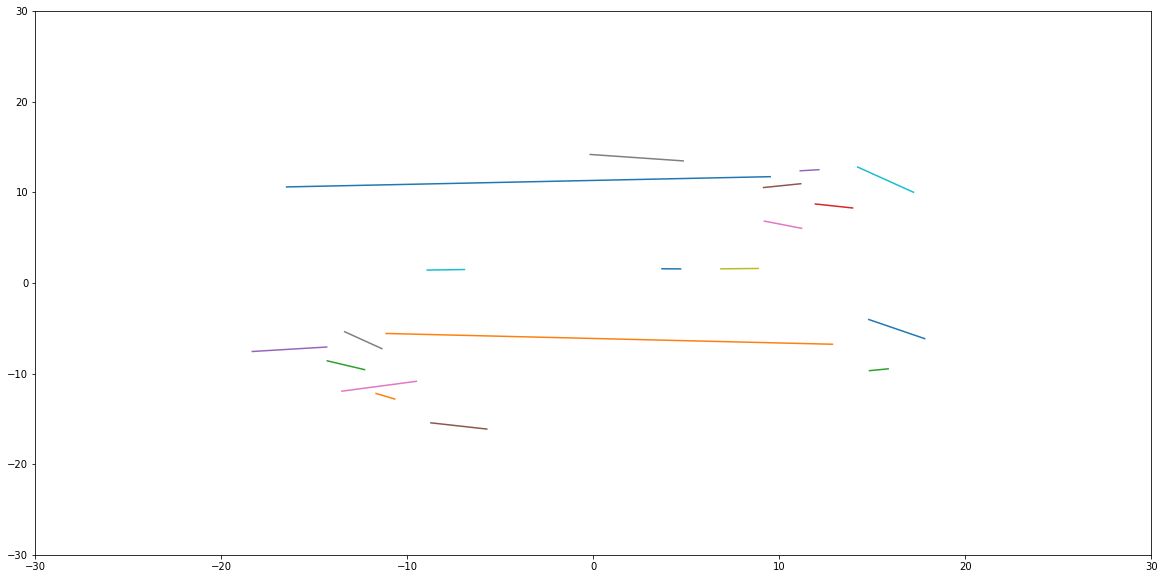

Number of prototype lane markings:  21


In [27]:
plt.figure(figsize=(20,10))
plt.xlim(-30,30)
plt.ylim(-30,30)

for l in ransaclines:
    plt.plot(l[0], l[1])
    
plt.show()
print("Number of prototype lane markings: ", len(ransaclines))

1. change clustering algorithm(no dbscan)
2. remove noise
3. line fitting algorithm